Features defined successfully!
Model A: 7 features
Model B: 8 features
Model C: 27 features


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


All models trained!


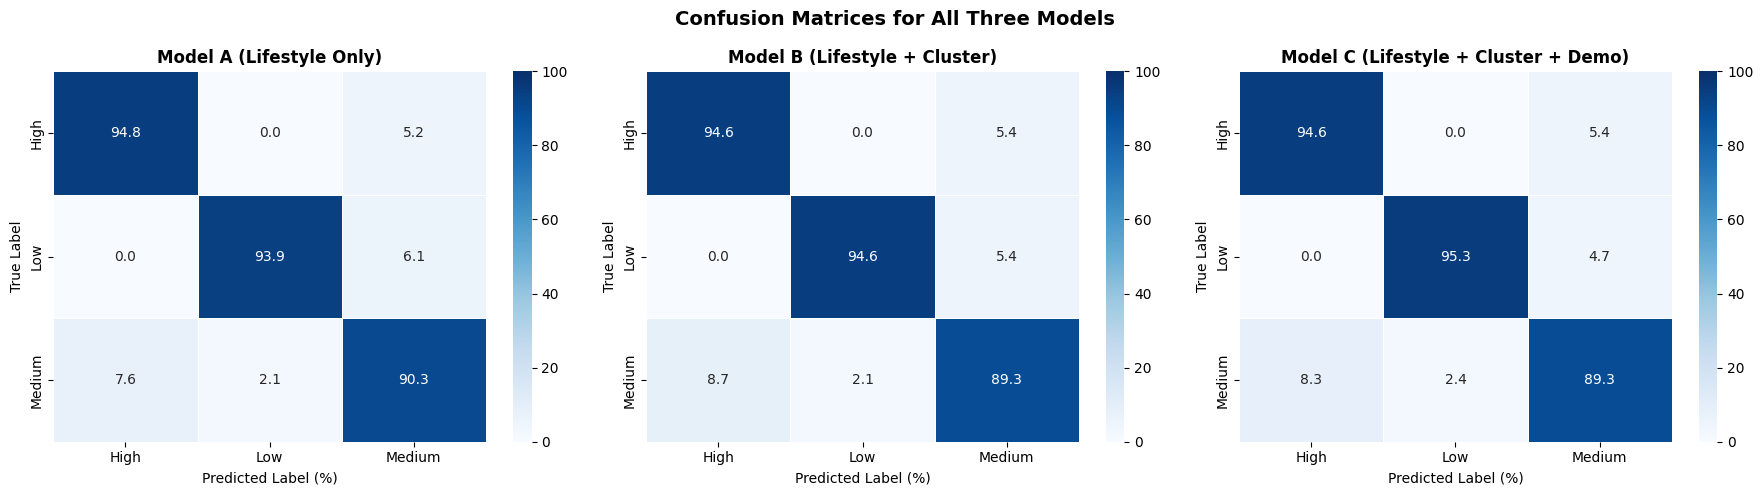

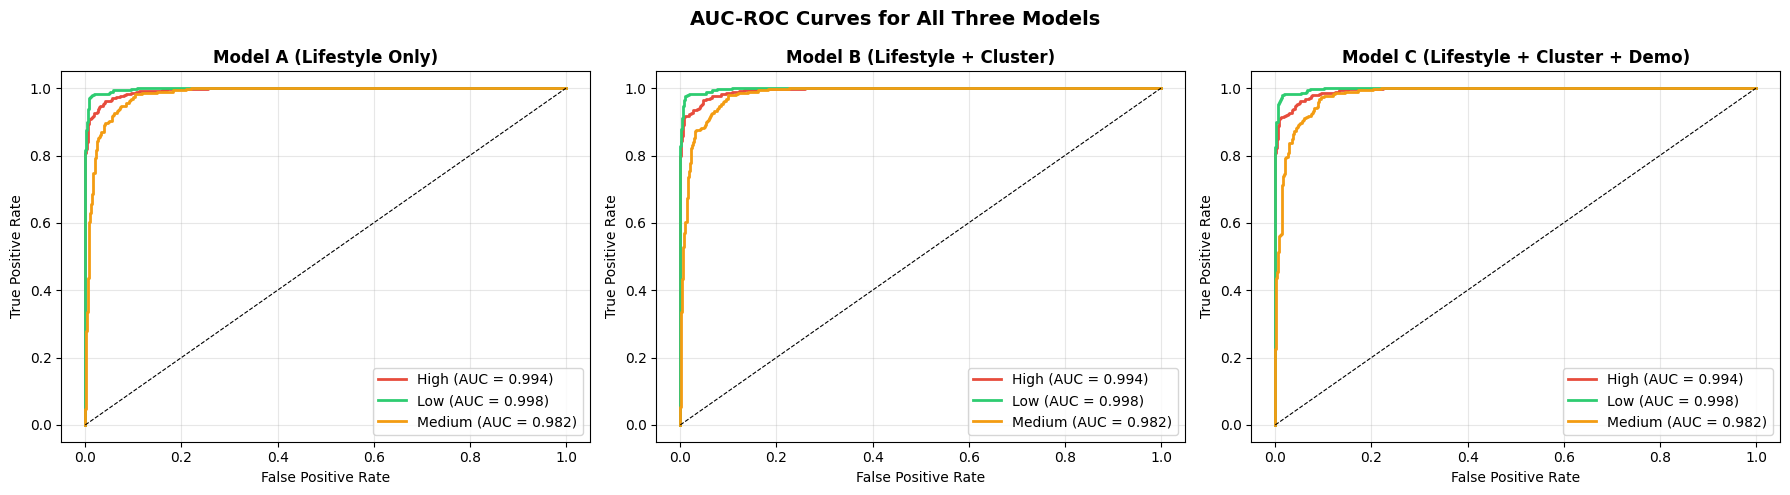


===== MODEL A (Lifestyle Only) =====
Test Accuracy: 0.9342
              precision    recall  f1-score   support

        High      0.959     0.948     0.953       539
         Low      0.979     0.939     0.959       296
      Medium      0.850     0.903     0.876       289

    accuracy                          0.934      1124
   macro avg      0.929     0.930     0.929      1124
weighted avg      0.936     0.934     0.935      1124

Macro AUC-ROC: 0.9915

===== MODEL B (Lifestyle + Cluster) =====
Test Accuracy: 0.9324
              precision    recall  f1-score   support

        High      0.953     0.946     0.950       539
         Low      0.979     0.946     0.962       296
      Medium      0.851     0.893     0.872       289

    accuracy                          0.932      1124
   macro avg      0.928     0.928     0.928      1124
weighted avg      0.934     0.932     0.933      1124

Macro AUC-ROC: 0.9914

===== MODEL C (Lifestyle + Cluster + Demo) =====
Test Accuracy: 0.93

In [1]:
# Evaluation Notebook — All Models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import label_binarize

# ============================================================
# 1. LOAD DATA
# ============================================================
train_df = pd.read_csv('../data/processed/train_with_clusters.csv')
val_df = pd.read_csv('../data/processed/val_with_clusters.csv')
test_df = pd.read_csv('../data/processed/test_with_clusters.csv')

target_col = 'Stress_Level'
classes = ['High', 'Low', 'Medium']

y_train = train_df[target_col]
y_val = val_df[target_col]
y_test = test_df[target_col]

# ============================================================
# 2. DEFINE FEATURES
# ============================================================
lifestyle_features = [
    col for col in train_df.columns
    if col.endswith("_Scaled") and not col.startswith("Age")
]
cluster_feature = ["Cluster"]

# Demographic features
demo_raw = []
if "Age_Scaled" in train_df.columns:
    demo_raw.append("Age_Scaled")
elif "Age" in train_df.columns:
    demo_raw.append("Age")

for col in ["Gender", "Occupation", "Country"]:
    if col in train_df.columns:
        demo_raw.append(col)

# One-hot encode demographics
demo_train = pd.get_dummies(train_df[demo_raw], drop_first=False)
demo_val = pd.get_dummies(val_df[demo_raw], drop_first=False)
demo_test = pd.get_dummies(test_df[demo_raw], drop_first=False)

# Align columns
demo_val = demo_val.reindex(columns=demo_train.columns, fill_value=0)
demo_test = demo_test.reindex(columns=demo_train.columns, fill_value=0)

features_A = lifestyle_features
features_B = lifestyle_features + cluster_feature

X_train_A = train_df[features_A]
X_val_A = val_df[features_A]
X_test_A = test_df[features_A]

X_train_B = train_df[features_B]
X_val_B = val_df[features_B]
X_test_B = test_df[features_B]

X_train_C = pd.concat([train_df[features_B].reset_index(drop=True),
                       demo_train.reset_index(drop=True)], axis=1)
X_val_C = pd.concat([val_df[features_B].reset_index(drop=True),
                     demo_val.reset_index(drop=True)], axis=1)
X_test_C = pd.concat([test_df[features_B].reset_index(drop=True),
                      demo_test.reset_index(drop=True)], axis=1)

print("Features defined successfully!")
print("Model A:", len(features_A), "features")
print("Model B:", len(features_B), "features")
print("Model C:", X_train_C.shape[1], "features")

# ============================================================
# 3. TRAIN MODELS
# ============================================================
model_A = LogisticRegression(multi_class="multinomial", solver="lbfgs",
                             max_iter=1000, random_state=42)
model_A.fit(X_train_A, y_train)

model_B = LogisticRegression(multi_class="multinomial", solver="lbfgs",
                             max_iter=1000, random_state=42)
model_B.fit(X_train_B, y_train)

model_C = LogisticRegression(multi_class="multinomial", solver="lbfgs",
                             max_iter=1000, random_state=42)
model_C.fit(X_train_C, y_train)

print("All models trained!")

# ============================================================
# 4. PREDICTIONS
# ============================================================
test_pred_A = model_A.predict(X_test_A)
test_pred_B = model_B.predict(X_test_B)
test_pred_C = model_C.predict(X_test_C)

test_prob_A = model_A.predict_proba(X_test_A)
test_prob_B = model_B.predict_proba(X_test_B)
test_prob_C = model_C.predict_proba(X_test_C)

y_test_bin = label_binarize(y_test, classes=classes)

# ============================================================
# 5. CONFUSION MATRICES
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, pred, title in zip(axes,
                           [test_pred_A, test_pred_B, test_pred_C],
                           ['Model A (Lifestyle Only)',
                            'Model B (Lifestyle + Cluster)',
                            'Model C (Lifestyle + Cluster + Demo)']):
    cm = confusion_matrix(y_test, pred, labels=classes)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    sns.heatmap(
        cm_pct,
        annot=True,
        fmt='.1f',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes,
        ax=ax,
        linewidths=0.5,
        vmin=0,
        vmax=100
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label (%)', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)

plt.suptitle('Confusion Matrices for All Three Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 6. AUC-ROC CURVES
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#E74C3C', '#2ECC71', '#F39C12']

for ax, prob, title in zip(axes,
                           [test_prob_A, test_prob_B, test_prob_C],
                           ['Model A (Lifestyle Only)',
                            'Model B (Lifestyle + Cluster)',
                            'Model C (Lifestyle + Cluster + Demo)']):
    for i, (cls, color) in enumerate(zip(classes, colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], prob[:, i])
        auc = roc_auc_score(y_test_bin[:, i], prob[:, i])
        ax.plot(fpr, tpr, color=color,
                label=f'{cls} (AUC = {auc:.3f})',
                linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.suptitle('AUC-ROC Curves for All Three Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('auc_roc_all.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 7. METRICS SUMMARY
# ============================================================
print("\n===== MODEL A (Lifestyle Only) =====")
print("Test Accuracy:", round(accuracy_score(y_test, test_pred_A), 4))
print(classification_report(y_test, test_pred_A, digits=3))
print("Macro AUC-ROC:", round(roc_auc_score(y_test_bin, test_prob_A, average='macro'), 4))

print("\n===== MODEL B (Lifestyle + Cluster) =====")
print("Test Accuracy:", round(accuracy_score(y_test, test_pred_B), 4))
print(classification_report(y_test, test_pred_B, digits=3))
print("Macro AUC-ROC:", round(roc_auc_score(y_test_bin, test_prob_B, average='macro'), 4))

print("\n===== MODEL C (Lifestyle + Cluster + Demo) =====")
print("Test Accuracy:", round(accuracy_score(y_test, test_pred_C), 4))
print(classification_report(y_test, test_pred_C, digits=3))
print("Macro AUC-ROC:", round(roc_auc_score(y_test_bin, test_prob_C, average='macro'), 4))

In [3]:
print("===== MODEL A (Lifestyle Only) =====")
print("Test Accuracy:", round(accuracy_score(y_test, test_pred_A), 4))
print(classification_report(y_test, test_pred_A, digits=3))
print("Macro AUC-ROC:", round(roc_auc_score(y_test_bin, test_prob_A, average='macro'), 4))

print("\n===== MODEL B (Lifestyle + Cluster) =====")
print("Test Accuracy:", round(accuracy_score(y_test, test_pred_B), 4))
print(classification_report(y_test, test_pred_B, digits=3))
print("Macro AUC-ROC:", round(roc_auc_score(y_test_bin, test_prob_B, average='macro'), 4))

print("\n===== MODEL C (Lifestyle + Cluster + Demo) =====")
print("Test Accuracy:", round(accuracy_score(y_test, test_pred_C), 4))
print(classification_report(y_test, test_pred_C, digits=3))
print("Macro AUC-ROC:", round(roc_auc_score(y_test_bin, test_prob_C, average='macro'), 4))

===== MODEL A (Lifestyle Only) =====
Test Accuracy: 0.9342
              precision    recall  f1-score   support

        High      0.959     0.948     0.953       539
         Low      0.979     0.939     0.959       296
      Medium      0.850     0.903     0.876       289

    accuracy                          0.934      1124
   macro avg      0.929     0.930     0.929      1124
weighted avg      0.936     0.934     0.935      1124

Macro AUC-ROC: 0.9915

===== MODEL B (Lifestyle + Cluster) =====
Test Accuracy: 0.9324
              precision    recall  f1-score   support

        High      0.953     0.946     0.950       539
         Low      0.979     0.946     0.962       296
      Medium      0.851     0.893     0.872       289

    accuracy                          0.932      1124
   macro avg      0.928     0.928     0.928      1124
weighted avg      0.934     0.932     0.933      1124

Macro AUC-ROC: 0.9914

===== MODEL C (Lifestyle + Cluster + Demo) =====
Test Accuracy: 0.934